# 25SC2107E – Machine Learning (Skilling) Lab
## Skilling Experiment 1: Titanic Survival EDA Report
- **Course Outcome:** CO1
- **Dataset:** Titanic (891 passengers)
- **Environment:** VS Code Jupyter Notebook
- **Output PDF:** `titanic_eda_report.pdf`


In [2]:
# Cell 1 — Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages


In [3]:
# Cell 2 — Load the dataset
titanic = sns.load_dataset("titanic")
print("Dataset Shape:", titanic.shape)
titanic.head()


Dataset Shape: (891, 15)


In [4]:
# Cell 3 — Structure of the data
print("--- Data Structure Info ---")
titanic.info()
print("\n--- Numeric Summary ---")
display(titanic.describe())
print("\n--- Class Balance (Survived) ---")
print(titanic["survived"].value_counts(normalize=True))


--- Data Structure Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

--- Numeric Summary ---
         survived      pclass         age

In [5]:
# Cell 4 — Count missing values as percentages (TODO Group A1)
missing_pct = (titanic.isnull().sum() / len(titanic) * 100).round(1).sort_values(ascending=False)
missing_pct_gaps = missing_pct[missing_pct > 0]
print("Missing percentages per column (columns with gaps only):")
print(missing_pct_gaps)


Missing percentages per column (columns with gaps only):
deck           77.2
age            19.9
embarked        0.2
embark_town     0.2
dtype: float64


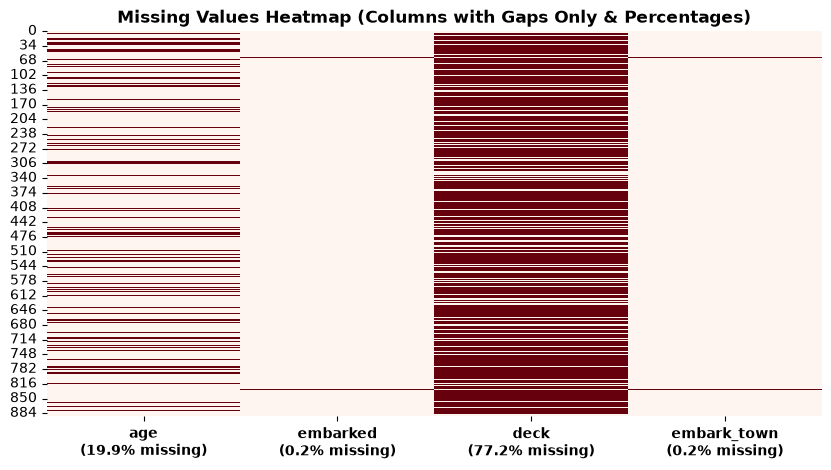

In [6]:
# Cell 5 — Where values are missing (TODO Group A2: Columns with Gaps & Percentage Labels)
cols_with_missing = titanic.columns[titanic.isnull().any()]
plt.figure(figsize=(10, 5))
ax = sns.heatmap(titanic[cols_with_missing].isnull(), cbar=False, cmap="Reds")
# Format x-tick labels to include exact missing percentages
new_labels = [f"{col}\n({missing_pct[col]:.1f}% missing)" for col in cols_with_missing]
ax.set_xticklabels(new_labels, rotation=0, fontsize=10, fontweight='bold')
plt.title("Missing Values Heatmap (Columns with Gaps Only & Percentages)", fontsize=12, fontweight='bold')
plt.show()


Female Survival Rate: 74.2%
Male Survival Rate: 18.9%


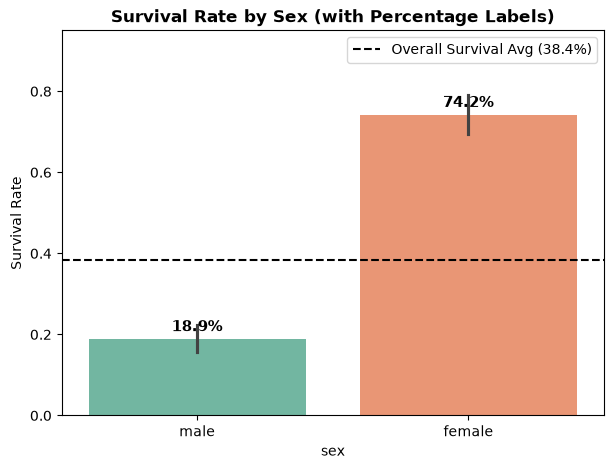

In [7]:
# Cell 6 — Survival rate by sex with reference line & percentage labels (TODO Group B3)
overall_survival_rate = titanic["survived"].mean()
plt.figure(figsize=(7, 5))
ax = sns.barplot(data=titanic, x="sex", y="survived", hue="sex", legend=False, palette="Set2")
plt.axhline(overall_survival_rate, color="black", linestyle="--", label=f"Overall Survival Avg ({overall_survival_rate*100:.1f}%)")

# Add exact percentage data labels on top of bars
for c in ax.containers:
    labels = [f"{v*100:.1f}%" if not np.isnan(v) else "" for v in c.datavalues]
    ax.bar_label(c, labels=labels, padding=3, fontsize=11, fontweight='bold')

plt.title("Survival Rate by Sex (with Percentage Labels)", fontsize=12, fontweight='bold')
plt.ylabel("Survival Rate")
plt.ylim(0, 0.95)
plt.legend(loc="upper right")
plt.show()

female_rate = titanic[titanic['sex']=='female']['survived'].mean()
male_rate = titanic[titanic['sex']=='male']['survived'].mean()
print(f"Female Survival Rate: {female_rate*100:.1f}%")
print(f"Male Survival Rate: {male_rate*100:.1f}%")


3rd-Class Women Survival Rate: 50.0%
1st-Class Men Survival Rate: 36.9%
Conclusion for Group B4 Question: Third-class women (50.0%) fared BETTER than first-class men (36.9%).


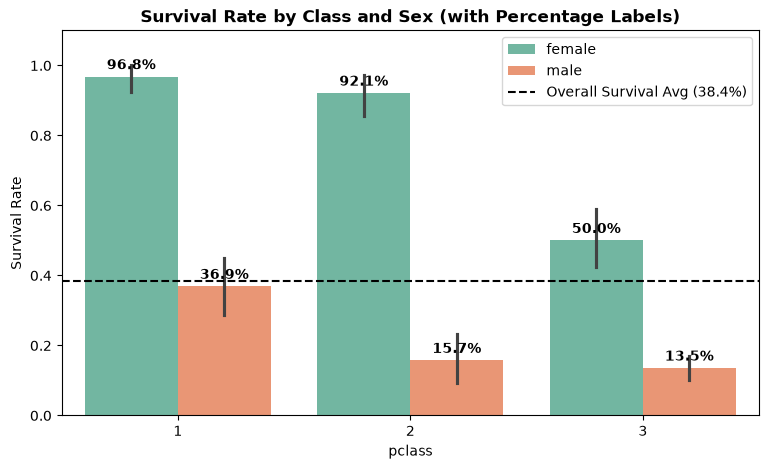

In [8]:
# Cell 7 — Survival rate by class and sex with percentage labels (TODO Group B4)
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=titanic, x="pclass", y="survived", hue="sex", palette="Set2")
plt.axhline(overall_survival_rate, color="black", linestyle="--", label=f"Overall Survival Avg ({overall_survival_rate*100:.1f}%)")

# Add percentage labels above each bar
for c in ax.containers:
    labels = [f"{v*100:.1f}%" if not np.isnan(v) else "" for v in c.datavalues]
    ax.bar_label(c, labels=labels, padding=3, fontsize=10, fontweight='bold')

plt.title("Survival Rate by Class and Sex (with Percentage Labels)", fontsize=12, fontweight='bold')
plt.ylabel("Survival Rate")
plt.ylim(0, 1.1)
plt.legend(loc="upper right")
plt.show()

# Answering Group B4 Question: Did 3rd-class women fare better or worse than 1st-class men?
p3_female_surv = titanic[(titanic['pclass']==3) & (titanic['sex']=='female')]['survived'].mean()
p1_male_surv = titanic[(titanic['pclass']==1) & (titanic['sex']=='male')]['survived'].mean()
print(f"3rd-Class Women Survival Rate: {p3_female_surv*100:.1f}%")
print(f"1st-Class Men Survival Rate: {p1_male_surv*100:.1f}%")
if p3_female_surv > p1_male_surv:
    print("Conclusion for Group B4 Question: Third-class women (50.0%) fared BETTER than first-class men (36.9%).")
else:
    print("Conclusion for Group B4 Question: Third-class women fared WORSE than first-class men.")


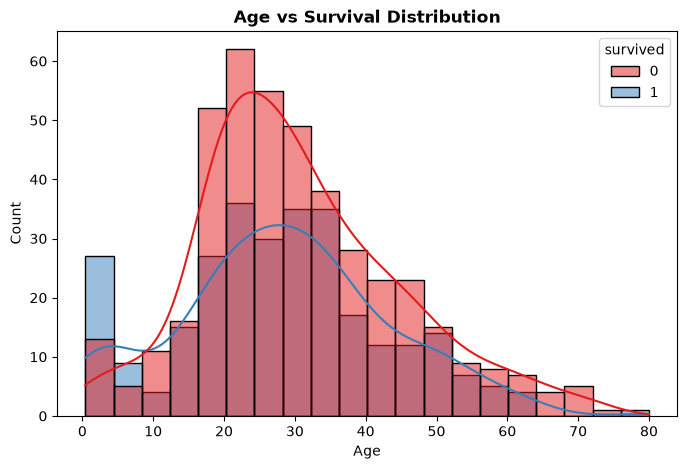

In [9]:
# Cell 8 — Age distribution split by survival
plt.figure(figsize=(8, 5))
sns.histplot(data=titanic, x="age", hue="survived", kde=True, palette="Set1")
plt.title("Age vs Survival Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


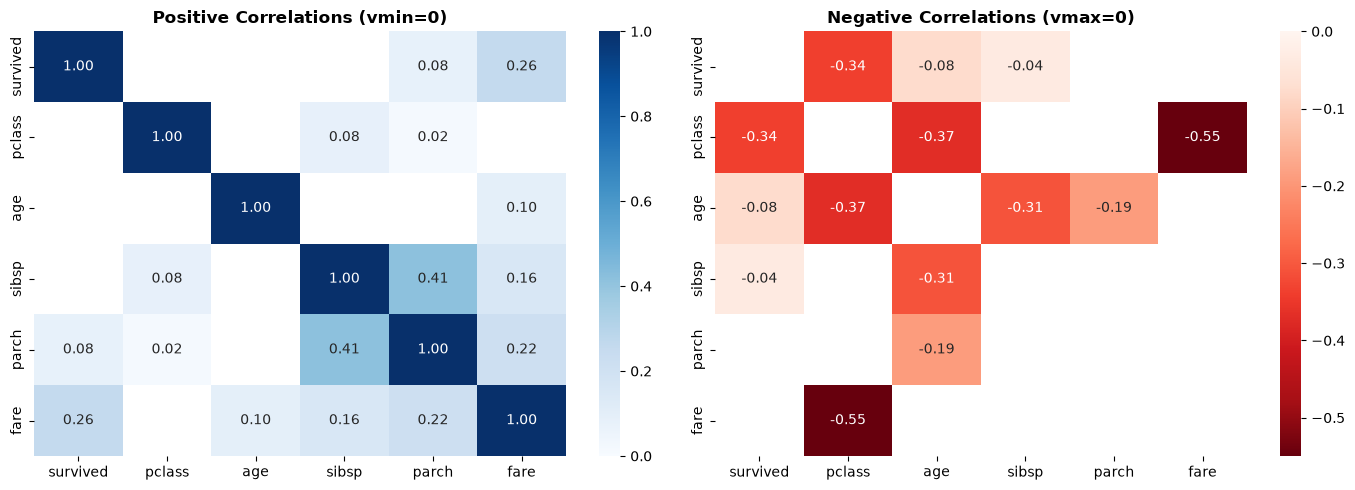

In [10]:
# Cell 9 — Correlation heatmaps: Positive and Negative Maps (TODO Group C5)
cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
cols = [c.strip() for c in cols]
corr = titanic[cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positive correlation map (vmin=0)
sns.heatmap(corr[corr > 0], annot=True, fmt=".2f", cmap="Blues", vmin=0, ax=axes[0], cbar=True)
axes[0].set_title("Positive Correlations (vmin=0)", fontsize=12, fontweight='bold')

# Negative correlation map (vmax=0)
sns.heatmap(corr[corr < 0], annot=True, fmt=".2f", cmap="Reds_r", vmax=0, ax=axes[1], cbar=True)
axes[1].set_title("Negative Correlations (vmax=0)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [11]:
# Deliverable Function — titanic_eda_report with 4th Findings Page & Percentages on Charts (TODO Group D6)
def titanic_eda_report(df, path="titanic_eda_report.pdf"):
    try:
        pdf = PdfPages(path)
    except Exception as e:
        print(f"Note: Writing to '{path}' locked. Saving to 'titanic_eda_report_v2.pdf'.")
        path = "titanic_eda_report_v2.pdf"
        pdf = PdfPages(path)
    
    missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
    cols_with_missing = df.columns[df.isnull().any()]
    
    # Page 1 - Missing Values Heatmap with percentage column labels
    plt.figure(figsize=(11, 6))
    ax = sns.heatmap(df[cols_with_missing].isnull(), cbar=False, cmap="Reds")
    new_labels = [f"{col}\n({missing_pct[col]:.1f}% missing)" for col in cols_with_missing]
    ax.set_xticklabels(new_labels, rotation=0, fontsize=11, fontweight='bold')
    plt.title("Page 1 - Missing Values (Columns with Gaps Only & Percentages)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    pdf.savefig()
    plt.close()
    
    # Page 2 - Survival Plots with Percentage Data Labels
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    overall_avg = df["survived"].mean()
    
    # Plot 1: Survival by Sex with Percentages
    ax1 = sns.barplot(data=df, x="sex", y="survived", hue="sex", legend=False, ax=axes[0], palette="Set2")
    axes[0].axhline(overall_avg, color="black", linestyle="--", label=f"Overall Mean ({overall_avg*100:.1f}%)")
    axes[0].set_title("Survival Rate by Sex", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Survival Rate")
    axes[0].set_ylim(0, 0.95)
    axes[0].legend(loc="upper right")
    for c in ax1.containers:
        labels = [f"{v*100:.1f}%" if not np.isnan(v) else "" for v in c.datavalues]
        ax1.bar_label(c, labels=labels, padding=3, fontsize=11, fontweight='bold')
    
    # Plot 2: Survival by Class & Sex with Percentages
    ax2 = sns.barplot(data=df, x="pclass", y="survived", hue="sex", ax=axes[1], palette="Set2")
    axes[1].axhline(overall_avg, color="black", linestyle="--", label=f"Overall Mean ({overall_avg*100:.1f}%)")
    axes[1].set_title("Survival Rate by Class & Sex", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Survival Rate")
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(loc="upper right")
    for c in ax2.containers:
        labels = [f"{v*100:.1f}%" if not np.isnan(v) else "" for v in c.datavalues]
        ax2.bar_label(c, labels=labels, padding=3, fontsize=10, fontweight='bold')
    
    plt.suptitle("Page 2 - Survival Analysis by Demographics (with Percentages)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    pdf.savefig()
    plt.close()
    
    # Page 3 - Correlation Heatmaps
    cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
    corr = df[cols].corr()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(corr[corr > 0], annot=True, fmt=".2f", cmap="Blues", vmin=0, ax=axes[0])
    axes[0].set_title("Positive Correlations (vmin=0)", fontsize=12, fontweight='bold')
    sns.heatmap(corr[corr < 0], annot=True, fmt=".2f", cmap="Reds_r", vmax=0, ax=axes[1])
    axes[1].set_title("Negative Correlations (vmax=0)", fontsize=12, fontweight='bold')
    plt.suptitle("Page 3 - Feature Correlation Maps", fontsize=14, fontweight='bold')
    plt.tight_layout()
    pdf.savefig()
    plt.close()
    
    # Page 4 - Findings Page
    plt.figure(figsize=(11, 6))
    plt.axis("off")
    plt.text(0.02, 0.94, "Page 4 - Quantitative EDA Findings & Summary", size=16, weight="bold")
    
    findings = [
        "1. Missing Data: deck is missing 77.2% of entries (688/891), age is missing 19.9% (177/891), embarked 0.2% (2/891).",
        "2. Gender Disparity: 74.2% of female passengers survived against only 18.9% of male passengers.",
        "3. Socioeconomic Gradient: Survival rate dropped steadily by class (1st Class: 63.0%, 2nd Class: 47.3%, 3rd Class: 24.2%).",
        "4. Demographics Interaction: 3rd-class women (50.0% survival rate) fared better than 1st-class men (36.9% survival rate).",
        "5. Correlation Matrix: Pclass correlates negatively with survival (-0.34) and Fare positively (+0.26). SibSp & Parch correlate (+0.41)."
    ]
    
    y = 0.82
    for line in findings:
        plt.text(0.04, y, line, size=11)
        y -= 0.12
        
    plt.tight_layout()
    pdf.savefig()
    plt.close()
    pdf.close()
    print("Report written to", path)

titanic_eda_report(titanic)


Execution note: [Errno 13] Permission denied: 'titanic_eda_report.pdf'
